# Import Libraries

In [2]:
pip install opencv-python matplotlib scikit-learn

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 2.3 MB/s eta 0:00:17
   - -------------------------------------- 1.0/40.2 MB 1.7 MB/s eta 0:00:23
   - -------------------------------------- 1.3/40.2 MB 1.7 MB/s eta 0:00:23
   - -------------------------------------- 1.8/40.2 MB 1.8 MB/s eta 0:00:22
   -- ------------------------------------- 2.1/40.2 MB 1.8 MB/s eta 0:00:22
   -- ------------------------------------- 2.4/40.2 MB 1.8 MB/s eta 0:00:21
   -- ------------------------------------- 2.6/40.2 MB 1.6 MB/s eta 0:00:24
   -- ------------------------------------- 2.9/40.2 MB 1.5 MB/s eta 0:00:25
   --- ------------------------------------ 3.1/40.2 MB 1.6 MB/s eta 0:00:24
   --- ------------------------------------ 3.7/40.2 MB 1.6 MB/s eta 0:00:24
   --- ------------------------------------ 3.9/40.2 MB 1.6 MB/s eta 0:00:23
   ---- -----


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1.Explore the Dataset

In [6]:
image_path = 'CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.jpg'
mask_path = 'segmentations/001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.png'

Load image and convert BGR (OpenCV default) to RGB (Matplotlib default)

In [7]:
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Load the ground truth segmentation mask in grayscale

In [8]:
gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Plotting

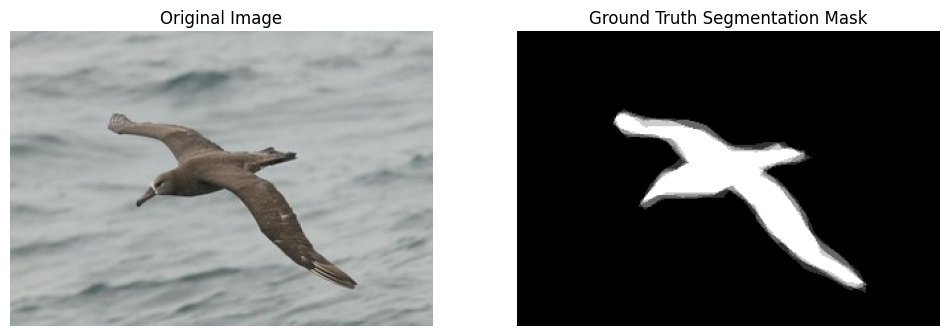

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title('Ground Truth Segmentation Mask')
axes[1].axis('off')

plt.show()

# 2.Segmentation Algorithms & Distance Metrics

Preprocess Ground Truth Mask to be strictly binary (0 and 1)

In [10]:
gt_binary = cv2.threshold(gt_mask, 127, 1, cv2.THRESH_BINARY)

Otsu's Thresholding Algorithm

In [11]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Apply a blur

In [12]:
blurred_gray = cv2.GaussianBlur(gray_img, (5, 5), 0)

In [13]:
otsu_mask = cv2.threshold(blurred_gray, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# K-Means Clustering Algorithm

Reshape

In [15]:
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

Apply K-means

In [19]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 2
_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

Reshape labels back to the original image shape

In [ ]:
kmeans_mask = labels.reshape((img.shape[0], img.shape[1]))

Distance Metrics Functions

In [27]:
if kmeans_mask[0, 0] == 1:
    kmeans_mask = 1 - kmeans_mask
def calculate_iou(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask)
    union = np.logical_or(pred_mask, true_mask)
    return np.sum(intersection) / np.sum(union)

def calculate_dice(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask)
    return 2.0 * np.sum(intersection) / (np.sum(pred_mask) + np.sum(true_mask))

# Calculate and Print Distances

In [28]:
print("--- Distance Metrics ---")
print(f"Otsu's Method -> IoU: {calculate_iou(otsu_mask, gt_binary):.4f} | Dice: {calculate_dice(otsu_mask, gt_binary):.4f}")
print(f"K-Means Method -> IoU: {calculate_iou(kmeans_mask, gt_binary):.4f} | Dice: {calculate_dice(kmeans_mask, gt_binary):.4f}")

--- Distance Metrics ---
Otsu's Method -> IoU: 0.6868 | Dice: 0.8143
K-Means Method -> IoU: 0.6868 | Dice: 0.8143


# Visualize the Results

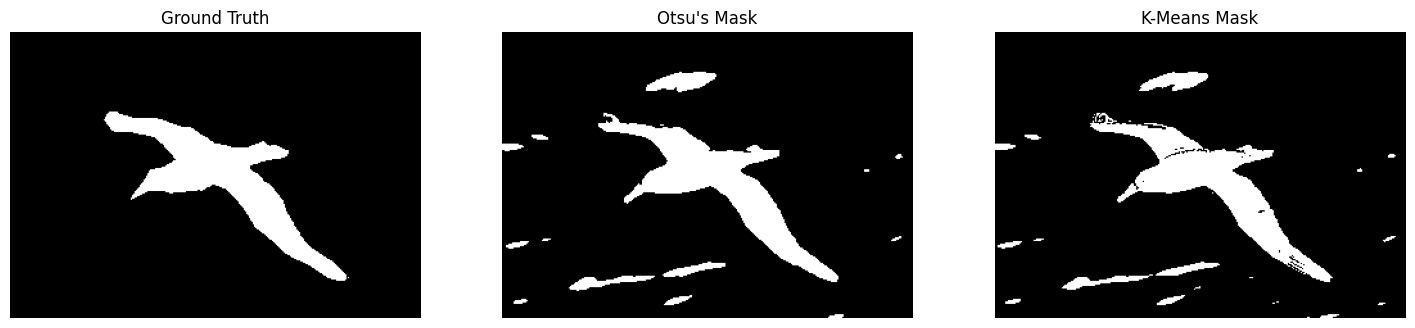

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(gt_binary, cmap='gray'); axes[0].set_title('Ground Truth')
axes[1].imshow(otsu_mask, cmap='gray'); axes[1].set_title("Otsu's Mask")
axes[2].imshow(kmeans_mask, cmap='gray'); axes[2].set_title('K-Means Mask')

for ax in axes:
    ax.axis('off')
plt.show()

# 3.Edge Detection

Basic Sobel Edge Detection

In [30]:
sobelx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

Normalize

In [31]:
sobel_combined = np.uint8(255 * sobel_combined / np.max(sobel_combined))

# Canny Edge Detection

Apply Gaussian

In [32]:
blurred_for_canny = cv2.GaussianBlur(gray_img, (5, 5), 0)

Calculate optimal thresholds

In [33]:
v = np.median(blurred_for_canny)
sigma = 0.33
lower_threshold = int(max(0, (1.0 - sigma) * v))
upper_threshold = int(min(255, (1.0 + sigma) * v))

Apply Canny

In [34]:
canny_edges = cv2.Canny(blurred_for_canny, lower_threshold, upper_threshold)

# Visualize Comparison

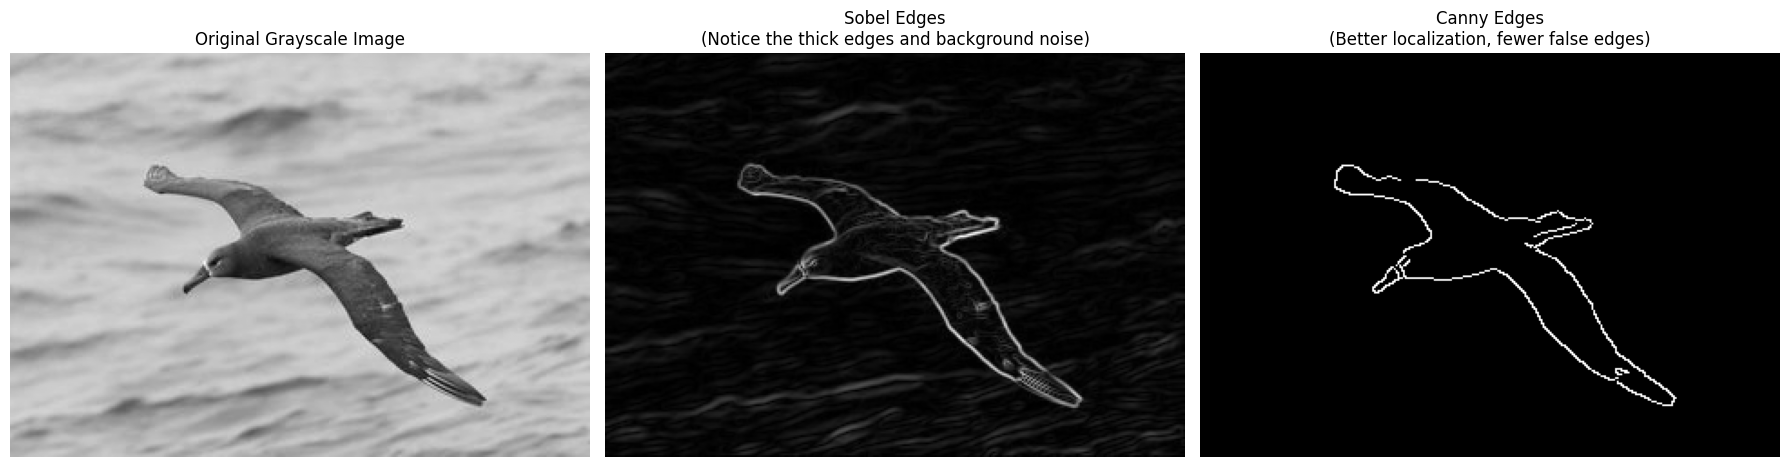

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original Grayscale Image')

axes[1].imshow(sobel_combined, cmap='gray')
axes[1].set_title('Sobel Edges\n(Notice the thick edges and background noise)')

axes[2].imshow(canny_edges, cmap='gray')
axes[2].set_title('Canny Edges\n(Better localization, fewer false edges)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()